In [249]:
import os
import gc
from PIL import Image
from tqdm.notebook import tqdm

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score

import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

from torchvision import transforms

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [4]:
class ArtifactDataset(Dataset):
    def __init__(self, root_dir, file_names, labels, transform=None):
        self.root_dir = root_dir
        self.file_names = file_names
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, index):
        img_path = os.path.join(self.root_dir, self.file_names[index])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, self.labels[index]

    def show(self, index):
        img_tensor, label = self[index]
        img_array = img_tensor.numpy().transpose((1, 2, 0))
        img_array = np.clip(img_array, 0, 1)

        plt.imshow(img_array)
        plt.title(f"Label: {label}")
        plt.axis("off")
        plt.show()

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((512, 512)),

    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(contrast=(0.8, 1.5), brightness=(0.8, 1.2)),
    transforms.RandomAdjustSharpness(sharpness_factor=2, p=0.5),

    transforms.CenterCrop(224),
    transforms.ToTensor(),

])

val_transforms = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

In [6]:
class ArtifactEncoder(nn.Module):
    def __init__(self, latent_size):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
        )
        self.flatten = nn.Flatten()
        self.in_latent = nn.Linear(128 * 14 * 14, latent_size)

    def forward(self, x):
        x = self.encoder(x)
        x = self.flatten(x)
        x = self.in_latent(x)

        return x

In [7]:
class ArtifactDecoder(nn.Module):
    def __init__(self, latent_size):
        super().__init__()

        self.out_latent = nn.Linear(latent_size, 128 * 14 * 14)
        self.unflatten = nn.Unflatten(1, (128, 14, 14))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),

            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(16),
            nn.GELU(),

            nn.ConvTranspose2d(16, 3, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.out_latent(x)
        x = self.unflatten(x)
        x = self.decoder(x)

        return x

In [8]:
class ArtifactAutoencoder(nn.Module):
    def __init__(self, latent_size):
        super().__init__()

        self.encoder = ArtifactEncoder(latent_size)
        self.decoder = ArtifactDecoder(latent_size)

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [9]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    epoch_loss = 0.0

    for inputs, _ in tqdm(loader, desc="Training", leave=False):
        optimizer.zero_grad()

        inputs = inputs.to(device)
        outputs = model(inputs)

        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)

    return avg_loss

In [10]:
@torch.no_grad()
def validate_one_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for inputs, _ in tqdm(loader, desc="Validating", leave=False):
            inputs = inputs.to(device)
            outputs = model(inputs)

            loss = criterion(outputs, inputs)
            epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)

    return avg_loss

<h4>Training</h4>

In [26]:
train_dir = "data/train"
all_files = os.listdir(train_dir)

zeros_files = [(0, f) for f in all_files if f.split("_")[-1][0] == '0']
ones_files = [(1, f) for f in all_files if f.split("_")[-1][0] == '1']

np.random.seed(42)
np.random.shuffle(ones_files)

num_val_ones = len(zeros_files)

train_val_files = ones_files[num_val_ones:]
train_val_labels, train_val_file_names = zip(*train_val_files)
train_file_names, val_file_names, train_labels, val_labels = train_test_split(
    train_val_file_names, train_val_labels, test_size=0.2, random_state=42
)

trh_files = zeros_files + ones_files[:num_val_ones]
trh_labels, trh_file_names = zip(*trh_files)

train_set = ArtifactDataset(train_dir, train_file_names, train_labels, train_transforms)
val_set = ArtifactDataset(train_dir, val_file_names, val_labels, val_transforms)
trh_set = ArtifactDataset(train_dir, trh_file_names, trh_labels, val_transforms)

train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
val_loader = DataLoader(val_set, batch_size=64, shuffle=False)
trh_loader = DataLoader(trh_set, batch_size=64, shuffle=False)

In [25]:
model = ArtifactAutoencoder(latent_size=512).to(device)
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=1e-3)

In [ ]:
num_epochs = 100
patience = 10
best_val_loss = float('inf')
epochs_no_improve = 0

writer = SummaryWriter('runs/AE_5')

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss = validate_one_epoch(model, val_loader, criterion)

    writer.add_scalars('Loss', {'train': train_loss, 'val': val_loss}, epoch + 1)

    print(f"Epoch {epoch+1}/{num_epochs} \n    Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "models/best_autoencoder.pth")
        print(f"    Model saved")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    print()

    model.eval()
    with torch.no_grad():
        val_inputs, _ = next(iter(val_loader))

        sample_input = val_inputs[0:1].to(device)
        sample_output = model(sample_input)

        img_original = sample_input[0].cpu().numpy().transpose((1, 2, 0))
        img_reconstructed = sample_output[0].cpu().numpy().transpose((1, 2, 0))
        img_original = np.clip(img_original, 0, 1)
        img_reconstructed = np.clip(img_reconstructed, 0, 1)

        fig, axes = plt.subplots(1, 2, figsize=(8, 4))

        axes[0].imshow(img_original)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(img_reconstructed)
        axes[1].set_title(f"Reconstructed")
        axes[1].axis("off")

        plt.show()

writer.close()

<h4>Threshold selection</h4>

In [125]:
@torch.no_grad()
def get_anomaly_scores(model, loader, criterion):
    model.eval()
    all_scores = []

    for inputs, _ in tqdm(loader, desc="Validating", leave=False):
        inputs = inputs.to(device)
        outputs = model(inputs)

        scores = criterion(outputs, inputs)
        scores = scores.mean(dim=[1, 2, 3])

        all_scores.extend(scores.cpu().numpy())

    return all_scores

In [210]:
latent_size = 512

model_path = f"models/artifact_eliminator_v{latent_size}.pth"

model = ArtifactAutoencoder(latent_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))

criterion = nn.MSELoss(reduction='none')

C:\Users\ACER\AppData\Local\Temp\ipykernel_5612\1908558715.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devi

In [211]:
anomaly_scores = get_anomaly_scores(model, trh_loader, criterion)

Validating:   0%|          | 0/6 [00:00<?, ?it/s]

<Axes: ylabel='Count'>

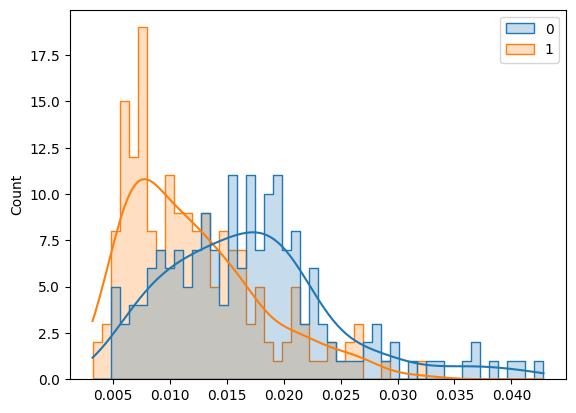

In [216]:
sns.histplot(
    x=anomaly_scores,
    hue=trh_labels,
    bins=50,
    kde=True,
    element="step"
)

In [208]:
def get_best_threshold(scores, labels, num_steps=200):
    thresholds = np.linspace(0, 1, num_steps)

    best_f1 = 0.0
    best_threshold = 0.0
    conf_matrix = None

    for threshold in thresholds:
        preds = scores > threshold

        f1 = f1_score(labels, preds, average='macro')

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            conf_matrix = confusion_matrix(labels, preds)

    print(f"Best threshold: {best_threshold}")
    print(f"Best f1: {best_f1}")
    print(f"Confusion matrix: \n{conf_matrix}")

    return best_threshold

In [214]:
threshold = get_best_threshold(anomaly_scores, trh_labels)

Best threshold: 0.020100502512562814
Best f1: 0.37073133297521293
Confusion matrix: 
[[133  47]
 [158  22]]


<h4>Testing</h4>

In [312]:
class Eliminator:
    def __init__(self, latent_size, threshold):
        self.model = ArtifactAutoencoder(latent_size).to(device)
        self.model.load_state_dict(torch.load(f"models/artifact_eliminator_v{latent_size}.pth", map_location=device))
        self.model.eval()

        self.transform = val_transforms
        self.threshold = threshold

        self.criterion = nn.MSELoss(reduction='none')

    @torch.no_grad()
    def predict_loader(self, loader):
        all_preds = []
        all_labels = []

        for inputs, labels in tqdm(loader, desc="Inference", leave=False):
            inputs = inputs.to(device)
            outputs = self.model(inputs)

            pixel_losses = self.criterion(outputs, inputs)
            image_scores = pixel_losses.mean(dim=[1, 2, 3]).cpu().numpy()

            preds = (image_scores <= self.threshold).astype(int)
            all_preds.extend(preds)
            all_labels.extend(labels)

        return np.array(all_preds), np.array(all_labels)

    @torch.no_grad()
    def predict_image(self, image_path):
        input_data = Image.open(image_path).convert("RGB")
        input_data = self.transform(input_data)

        if input_data.dim() == 3:
            input_data = input_data.unsqueeze(0)

        input_data = input_data.to(device)
        output_data = self.model(input_data)

        pixel_error = self.criterion(input_data, output_data)
        image_score = pixel_error.mean().item()

        img_orig = np.clip(input_data.squeeze(0).cpu().numpy().transpose((1, 2, 0)), 0, 1)
        img_recon = np.clip(output_data.squeeze(0).cpu().numpy().transpose((1, 2, 0)), 0, 1)
        heatmap = pixel_error[0].mean(dim=0).cpu().numpy()

        fig, axes = plt.subplots(1, 4, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1, 1, 0.05]})

        pred_label = 1 if image_score <= self.threshold else 0

        axes[0].imshow(img_orig)
        axes[0].set_title("Original")
        axes[0].axis("off")

        axes[1].imshow(img_recon)
        axes[1].set_title("Reconstructed")
        axes[1].axis("off")

        hm = axes[2].imshow(heatmap, cmap='hot')
        axes[2].set_title("Error Map")
        axes[2].axis("off")

        fig.colorbar(hm, cax=axes[3])

        plt.tight_layout()
        plt.show()

        return pred_label, image_score, self.threshold

In [313]:
test_dir = 'data/test/'

all_test_files = os.listdir(test_dir)
all_test_labels = [int(f.split('_')[-1].split('.')[0]) for f in all_test_files]

test_set = ArtifactDataset(test_dir, all_test_files, all_test_labels, val_transforms)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

In [314]:
eliminator = Eliminator(latent_size, threshold)

C:\Users\ACER\AppData\Local\Temp\ipykernel_5612\3071223089.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.model.load_state_dict(torch.load(f"models/artifact_elimin

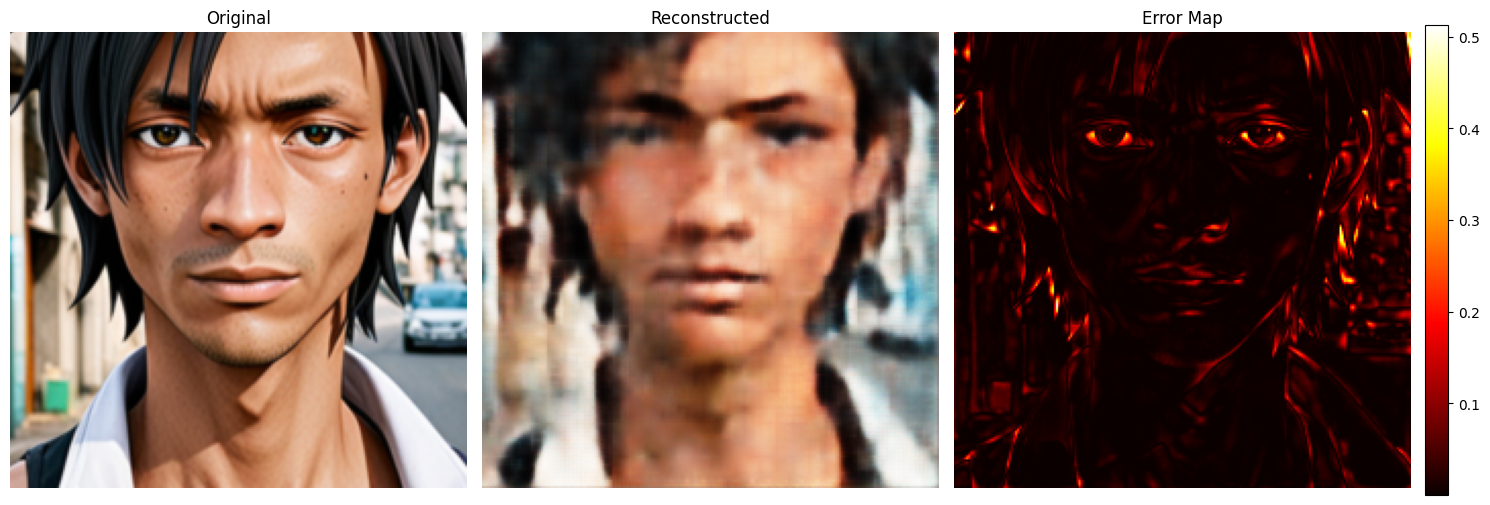

Real label:      1
Predicted label: 1
Score:           0.0149
Threshold:       0.0201


In [323]:
input_id = int(input("Enter Test ID: "))
test_id = input_id - 1

img_name = test_set.file_names[test_id]
img_path = os.path.join(test_dir, img_name)
real_label = test_set.labels[test_id]

pred_label, score, threshold = eliminator.predict_image(img_path)

print(f"Real label:      {real_label}")
print(f"Predicted label: {pred_label}")
print(f"Score:           {score:.4f}")
print(f"Threshold:       {threshold:.4f}")

In [253]:
test_preds, test_labels_true = eliminator.predict_loader(test_loader)
test_f1_micro = f1_score(test_labels_true, test_preds, average='micro')
test_f1_macro = f1_score(test_labels_true, test_preds, average='macro')
test_f1_weighted = f1_score(test_labels_true, test_preds, average='weighted')

print(f"Test Micro F1: {test_f1_micro:.4f}")
print(f"Test Macro F1: {test_f1_macro:.4f}")
print(f"Test Weighted F1: {test_f1_weighted:.4f}")
print("Confusion Matrix:\n", confusion_matrix(test_labels_true, test_preds))

Inference:   0%|          | 0/4 [00:00<?, ?it/s]

Test Micro F1: 0.8350
Test Macro F1: 0.5869
Test Weighted F1: 0.8430
Confusion Matrix:
 [[  6  14]
 [ 19 161]]


<h4>Memory cleaning</h4>

In [15]:
def clear_memory(*var_names):
    for var in var_names:
        if var in globals():
            del globals()[var]

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [324]:
clear_memory('model', 'optimizer', 'eliminator')